In [2]:
import numpy as np
states=list(map(str.strip,input("Enter the states(comma-separated):").split(',')))
observations=list(map(str.strip,input("Enter the possible observations(comma-separated):").split(',')))
observation_seq=list(map(str.strip,input(f"Enter the observation sequence as space_separated names(options:{observations}):").split()))
try:
    observation_indices=[]
    for obs in observation_seq:
        observation_indices.append(observations.index(obs))
except ValueError as e:
    print(f"Error:{e}.Please make sure your observation sequence contains only valid options:{observations}.")
    exit()
print("\nEnter the state transition probabilities:")
transition_matrix=np.zeros((len(states),len(states)))
for i in range(len(states)):
    for j in range(len(states)):
        transition_matrix[i,j]=float(input(f"P({states[j]}|{states[i]}):"))
print("\nEnter the emission probabilities:")
emission_matrix=np.zeros((len(states),len(observations)))
for i in range(len(states)):
    for j in range(len(observations)):
        emission_matrix[i,j]=float(input(f"P({observations[j]}|{states[i]}):"))
initial_probabilities=np.zeros(len(states))
print("\nEnter the initial state probabilities(comma-separated):")
initial_probabilities=list(map(float,input(f"Enter initial probabilities for{states}:").split(',')))

def forward_procedure(observation_seq,transition_matrix,emission_matrix,initial_probabilities):
    num_states=len(transition_matrix)
    num_observations=len(observation_seq)
    forward_matrix=np.zeros((num_states,num_observations))
    for i in range(num_states):
        forward_matrix[i, 0]=initial_probabilities[i] * emission_matrix[i, observation_seq[0]]
    for t in range(1,num_observations):
        for j in range(num_states):
            forward_matrix[j,t]=sum(forward_matrix[i,t-1]*transition_matrix[i,j] for i in range(num_states))*emission_matrix[j,observation_seq[t]]
    prob_observation=sum(forward_matrix[i,num_observations-1]for i in range(num_states))
    return forward_matrix,prob_observation

forward_matrix,prob_observation=forward_procedure(observation_indices,transition_matrix,emission_matrix,initial_probabilities)
print("\nForward Matrix:\n",forward_matrix)
print("Probability of observation sequence:",prob_observation)

def backward_procedure(observation_seq,transition_matrix,emission_matrix,initial_probabilities):
    num_states=len(transition_matrix)
    num_observations=len(observation_seq)
    backward_matrix=np.zeros((num_states,num_observations))
    backward_matrix[:,num_observations-1]=1
    for  t in range(num_observations-2,-1,-1):
        for i in range(num_states):
            backward_matrix[i,t]=sum(transition_matrix[i,j]*emission_matrix[j, observation_seq[t+1]]*backward_matrix[j,t+1]for j in range(num_states))
    prob_observation=sum(initial_probabilities[i]*emission_matrix[i, observation_seq[0]]*backward_matrix[i,0]for i in range(num_states))
    return backward_matrix,prob_observation

backward_matrix,prob_observation=backward_procedure(observation_indices,transition_matrix,emission_matrix,initial_probabilities)
print("\nBackward Matrix:\n",backward_matrix)
print("Probability of observation sequence:",prob_observation)

Enter the states(comma-separated):cp,ip
Enter the possible observations(comma-separated):lem,icet,cola
Enter the observation sequence as space_separated names(options:['lem', 'icet', 'cola']):lem icet cola

Enter the state transition probabilities:
P(cp|cp):0.7
P(ip|cp):0.5
P(cp|ip):0.3
P(ip|ip):0.5

Enter the emission probabilities:
P(lem|cp):0.3
P(icet|cp):0.1
P(cola|cp):0.6
P(lem|ip):0.2
P(icet|ip):0.7
P(cola|ip):0.1

Enter the initial state probabilities(comma-separated):
Enter initial probabilities for['cp', 'ip']:1.0,0.0

Forward Matrix:
 [[0.3     0.021   0.02772]
 [0.      0.105   0.0063 ]]
Probability of observation sequence: 0.034019999999999995

Backward Matrix:
 [[0.1134 0.47   1.    ]
 [0.0946 0.23   1.    ]]
Probability of observation sequence: 0.03401999999999999


In [21]:
import numpy as np
from hmmlearn import hmm

# Define the HMM parameters
states = ["cp", "ip"]
n_states = len(states)

observations = ["lem", "icet", "cola"]
n_observations = len(observations)

start_probability = np.array([1.0, 0.0])

transition_probability = np.array([
    [0.7, 0.3],
    [0.5, 0.5]
])

emission_probability = np.array([
    [0.3, 0.1, 0.6],
    [0.2, 0.7, 0.1]
])

# Create the HMM model
model = hmm.CategoricalHMM(n_components=n_states)
model.startprob_ = start_probability
model.transmat_ = transition_probability
model.emissionprob_ = emission_probability

# Define the observation sequence
observations_sequence = np.array([0, 1, 2]).reshape(-1, 1)  # lem,icet,cola

# ---Forward Algorithm---
# Calculate the forward probabilities
forward_probs = model.predict_proba(observations_sequence)

print("Forward Probabilities:")
print(forward_probs)

# ---Backward Algorithm---
# Calculate the backward probabilities
_, backward_probs = model.score_samples(observations_sequence)

# Convert log probabilities to probabilities
backward_probs = np.exp(backward_probs)

print("\nBackward Probabilities:")
print(backward_probs)

# ---Final Probability---
# Calculate the final probability by summing the probabilities of all states at the final time step
final_prob_forward = np.sum(forward_probs[-1])  # Using forward probabilities
final_prob_backward = np.sum(backward_probs[0] * start_probability * emission_probability[:, observations_sequence[0][0]])  # Using backward probabilities

print(f"\nFinal Probability (Forward): {final_prob_forward:.4f}")
print(f"Final Probability (Backward): {final_prob_backward:.4f}")

Forward Probabilities:
[[1.   0.  ]
 [0.3  0.7 ]
 [0.88 0.12]]

Backward Probabilities:
[[2.71828183 1.        ]
 [1.34985881 2.01375271]
 [2.41089971 1.12749685]]

Final Probability (Forward): 1.0000
Final Probability (Backward): 0.8155


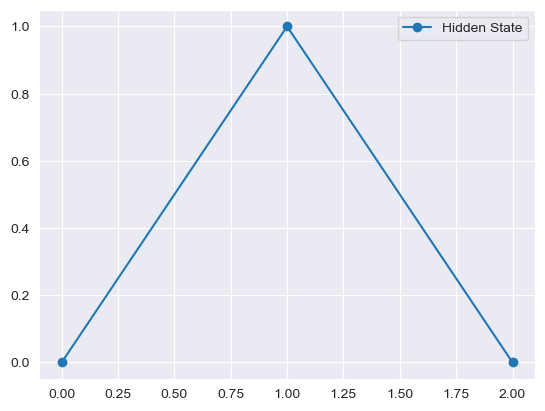

In [24]:
# Plot the results
import seaborn as sns
import matplotlib.pyplot as plt
hidden_states = model.predict(observations_sequence)
sns.set_style("darkgrid")
plt.plot(hidden_states, '-o', label="Hidden State")
plt.legend()
plt.show()

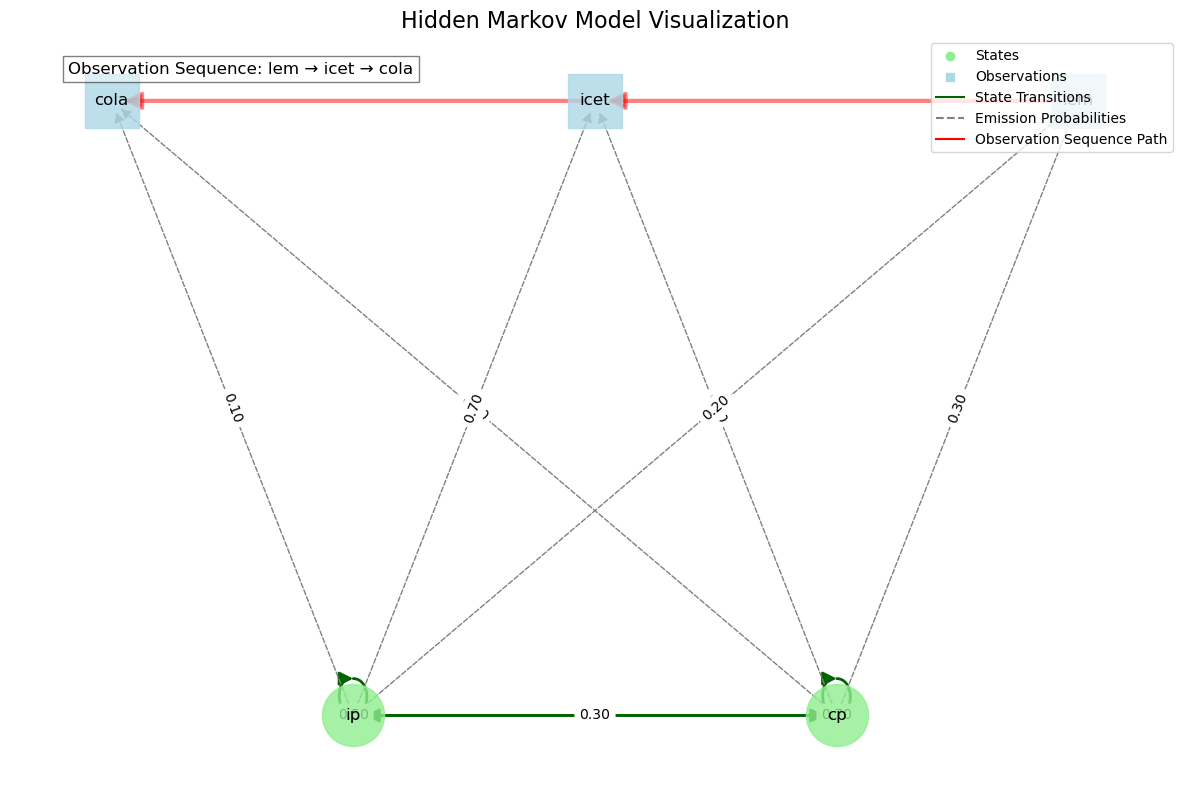

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add nodes with subset attributes (0 for states, 1 for observations)
for state in states:
    G.add_node(state, subset=0)  # States in layer 0

for obs in observations:
    G.add_node(obs, subset=1)  # Observations in layer 1

# Add edges with transition probabilities
for i, from_state in enumerate(states):
    for j, to_state in enumerate(states):
        prob = transition_matrix[i, j]
        if prob > 0:
            G.add_edge(from_state, to_state, weight=prob, label=f"{prob:.2f}")

# Add emission edges
for i, state in enumerate(states):
    for j, obs in enumerate(observations):
        prob = emission_matrix[i, j]
        if prob > 0:
            G.add_edge(state, obs, weight=prob, label=f"{prob:.2f}", style='dashed')

# Get positions using multipartite layout
pos = nx.multipartite_layout(G, align='horizontal', scale=2)

# Manually adjust positions for better readability
for node in G.nodes():
    if G.nodes[node]['subset'] == 1:  # If observation node
        pos[node][1] += 0.5  # Move observation nodes down slightly

# Draw the graph
plt.figure(figsize=(12, 8))

# Draw state nodes (subset 0)
nx.draw_networkx_nodes(G, pos, nodelist=states, node_size=2000, 
                      node_color='lightgreen', alpha=0.8)

# Draw observation nodes (subset 1)
nx.draw_networkx_nodes(G, pos, nodelist=observations, node_size=1500, 
                      node_color='lightblue', alpha=0.8, node_shape='s')

# Draw state transitions (solid edges)
state_edges = [(u, v) for (u, v, d) in G.edges(data=True) if v in states]
nx.draw_networkx_edges(G, pos, edgelist=state_edges, width=2, 
                      edge_color='darkgreen', arrowsize=20)

# Draw emission edges (dashed edges)
obs_edges = [(u, v) for (u, v, d) in G.edges(data=True) if v in observations]
nx.draw_networkx_edges(G, pos, edgelist=obs_edges, width=1, 
                      edge_color='gray', style='dashed', arrowsize=15)

# Draw labels
node_labels = {node: node for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=12)

# Draw edge labels
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

# Highlight observation sequence path if provided
if 'observation_seq' in locals() and len(observation_seq) > 1:
    path_edges = []
    for i in range(len(observation_seq)-1):
        path_edges.append((observation_seq[i], observation_seq[i+1]))
    
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, width=3, 
                          edge_color='red', alpha=0.5, arrowsize=25)

# Add title and legend
plt.title("Hidden Markov Model Visualization", fontsize=16)
if 'observation_seq' in locals():
    plt.text(0.05, 0.95, f"Observation Sequence: {' → '.join(observation_seq)}", 
             transform=plt.gca().transAxes, fontsize=12, 
             bbox=dict(facecolor='white', alpha=0.5))

# Add legend
plt.scatter([], [], color='lightgreen', label='States')
plt.scatter([], [], color='lightblue', marker='s', label='Observations')
plt.plot([], [], color='darkgreen', label='State Transitions')
plt.plot([], [], color='gray', linestyle='dashed', label='Emission Probabilities')
if 'observation_seq' in locals() and len(observation_seq) > 1:
    plt.plot([], [], color='red', label='Observation Sequence Path')
plt.legend(loc='upper right')

plt.axis('off')
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_3940\555218812.py:72: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, label='Transition Probability', shrink=0.7)


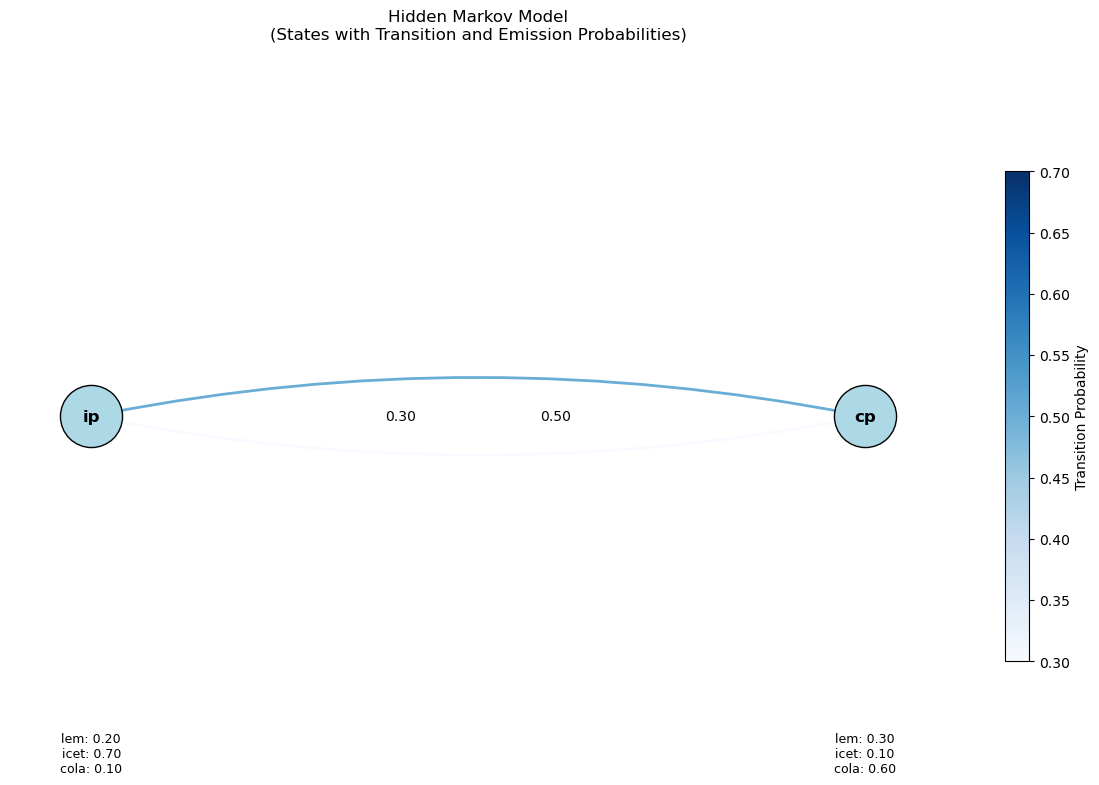

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np

# Create a directed graph
G = nx.DiGraph()

# Add nodes (states)
G.add_nodes_from(states)

# Add edges with transition probabilities
for i, from_state in enumerate(states):
    for j, to_state in enumerate(states):
        prob = transition_matrix[i, j]
        if prob > 0:  # Only draw edges with non-zero probability
            G.add_edge(from_state, to_state, weight=prob, label=f"{prob:.2f}")

# Node positions using circular layout
pos = nx.circular_layout(G)

# Prepare edge labels
edge_labels = nx.get_edge_attributes(G, 'label')

# Prepare edge weights for color mapping
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
norm = Normalize(vmin=min(edge_weights), vmax=max(edge_weights))
cmap = plt.cm.Blues

# Draw the graph
plt.figure(figsize=(12, 8))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue', edgecolors='black')

# Draw edges with color based on probability
edges = nx.draw_networkx_edges(
    G, pos, width=2, 
    edge_color=edge_weights, 
    edge_cmap=cmap,
    connectionstyle='arc3,rad=0.1'  # Curved edges to avoid overlap
)

# Add edge labels
nx.draw_networkx_edge_labels(
    G, pos, 
    edge_labels=edge_labels,
    font_size=10,
    label_pos=0.6  # Adjust label position along edge
)

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# Add emission probabilities as node attributes (displayed separately)
emission_labels = {}
for i, state in enumerate(states):
    emission_str = "\n".join([f"{obs}: {emission_matrix[i,j]:.2f}" 
                            for j, obs in enumerate(observations)])
    emission_labels[state] = emission_str

# Add emission probabilities as text near nodes
for state in states:
    x, y = pos[state]
    plt.text(x, y-0.15, emission_labels[state], 
             ha='center', va='top', fontsize=9, 
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Add colorbar for edge weights
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, label='Transition Probability', shrink=0.7)

# Add title and adjust layout
plt.title("Hidden Markov Model\n(States with Transition and Emission Probabilities)", pad=20)
plt.tight_layout()
plt.axis('off')

# Show the plot
plt.show()